In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn import metrics as mt

# Load data
df = pd.read_csv('data_karyawan.csv')

In [ ]:
# Basic info
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   usia              100 non-null    int64  
 1   pengalaman_kerja  95 non-null     float64
 2   jenis_kelamin     100 non-null    object 
 3   pendidikan        100 non-null    object 
 4   gaji              100 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 4.0+ KB
None
             usia  pengalaman_kerja          gaji
count  100.000000         95.000000  1.000000e+02
mean    37.910000          8.442105  5.039610e+06
std     12.219454          6.011896  1.086690e+06
min     18.000000          0.000000  1.759000e+06
25%     26.750000          3.500000  4.330250e+06
50%     38.000000          8.000000  5.067000e+06
75%     46.250000         13.500000  5.681500e+06
max     59.000000         19.000000  8.853000e+06


In [ ]:
# Check for missing values
print(df.isnull().sum())

usia                0
pengalaman_kerja    5
jenis_kelamin       0
pendidikan          0
gaji                0
dtype: int64


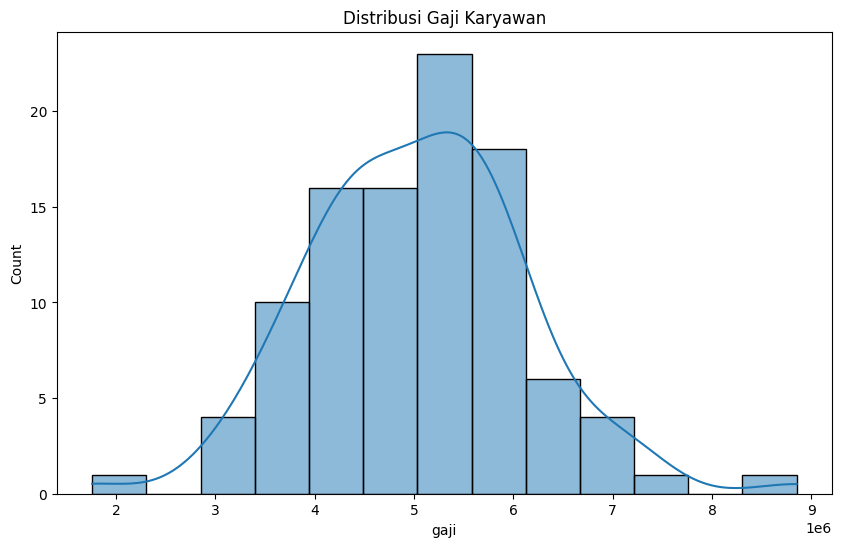

In [ ]:
# Visualisasi distribusi gaji
plt.figure(figsize=(10,6))
sns.histplot(df['gaji'], kde=True)
plt.title('Distribusi Gaji Karyawan')
plt.show()

In [ ]:
print("Missing values sebelum handling:")
print(df.isnull().sum())

Missing values sebelum handling:
usia                0
pengalaman_kerja    5
jenis_kelamin       0
pendidikan          0
gaji                0
dtype: int64


In [ ]:
#  Handle missing values
df['pengalaman_kerja'].fillna(df['pengalaman_kerja'].median(), inplace=True)

<ipython-input-6-d2b8e3324d81>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['pengalaman_kerja'].fillna(df['pengalaman_kerja'].median(), inplace=True)


In [ ]:
# Handling Outlier
Q1 = df['gaji'].quantile(0.25)
Q3 = df['gaji'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

In [ ]:
df = df[(df['gaji'] >= lower_bound) & (df['gaji'] <= upper_bound)]
df = df.reset_index(drop=True)

In [ ]:
#Konversi variabel kategorikal ke numerik untuk analisis korelasi
df['jenis_kelamin'] = df['jenis_kelamin'].map({'Pria': 1, 'Wanita': 0})

In [ ]:
# Pendidikan: order encoding
pendidikan_order = {'SMA': 1, 'D3': 2, 'S1': 3, 'S2': 4}
df['pendidikan'] = df['pendidikan'].map(pendidikan_order)

In [ ]:
#Feature Engineering
df['usia_pengalaman'] = df['usia'] * df['pengalaman_kerja']
df['pengalaman_kuadrat'] = df['pengalaman_kerja']**2

In [ ]:
#Pisahkan Features dan Target
features = ['usia', 'pengalaman_kerja', 'jenis_kelamin', 'pendidikan', 'usia_pengalaman', 'pengalaman_kuadrat']
X = df[features]
y = df['gaji']

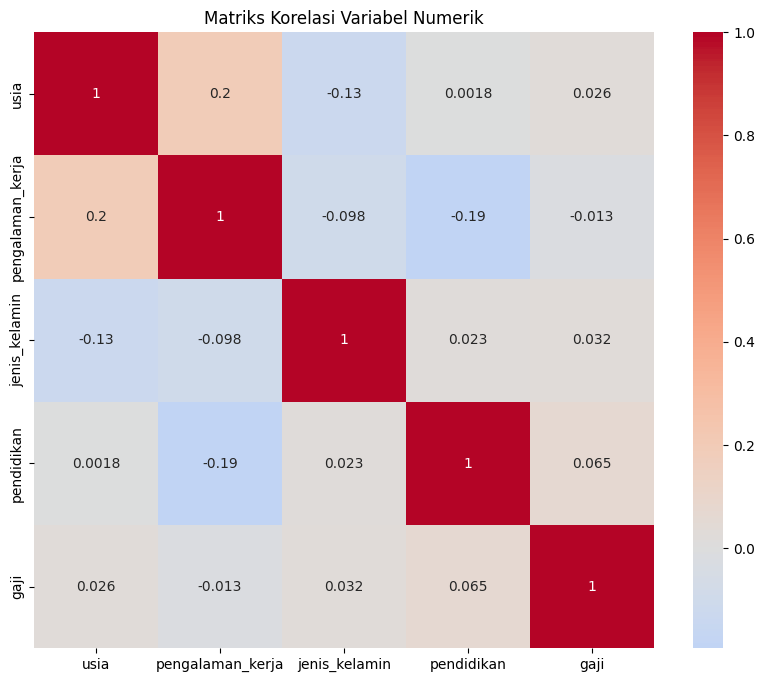

In [ ]:
# Hitung matriks korelasi
corr_matrix = df[['usia', 'pengalaman_kerja', 'jenis_kelamin', 'pendidikan', 'gaji']].corr()

# Visualisasi heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriks Korelasi Variabel Numerik')
plt.show()

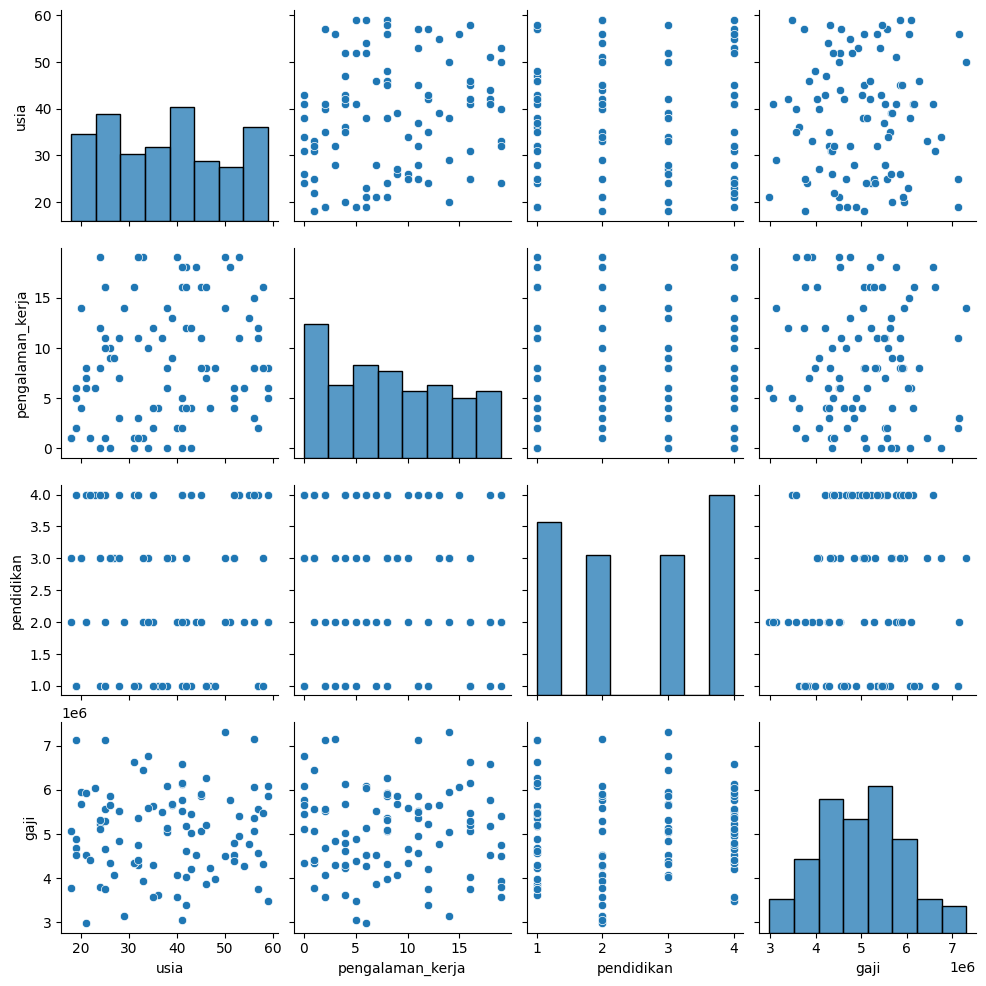

In [ ]:
# Pair plot untuk melihat hubungan multivariat
sns.pairplot(df[['usia', 'pengalaman_kerja', 'pendidikan', 'gaji']])
plt.show()

<ipython-input-15-451107d2d612>:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.countplot(x='pendidikan', data=df, palette='Set2')


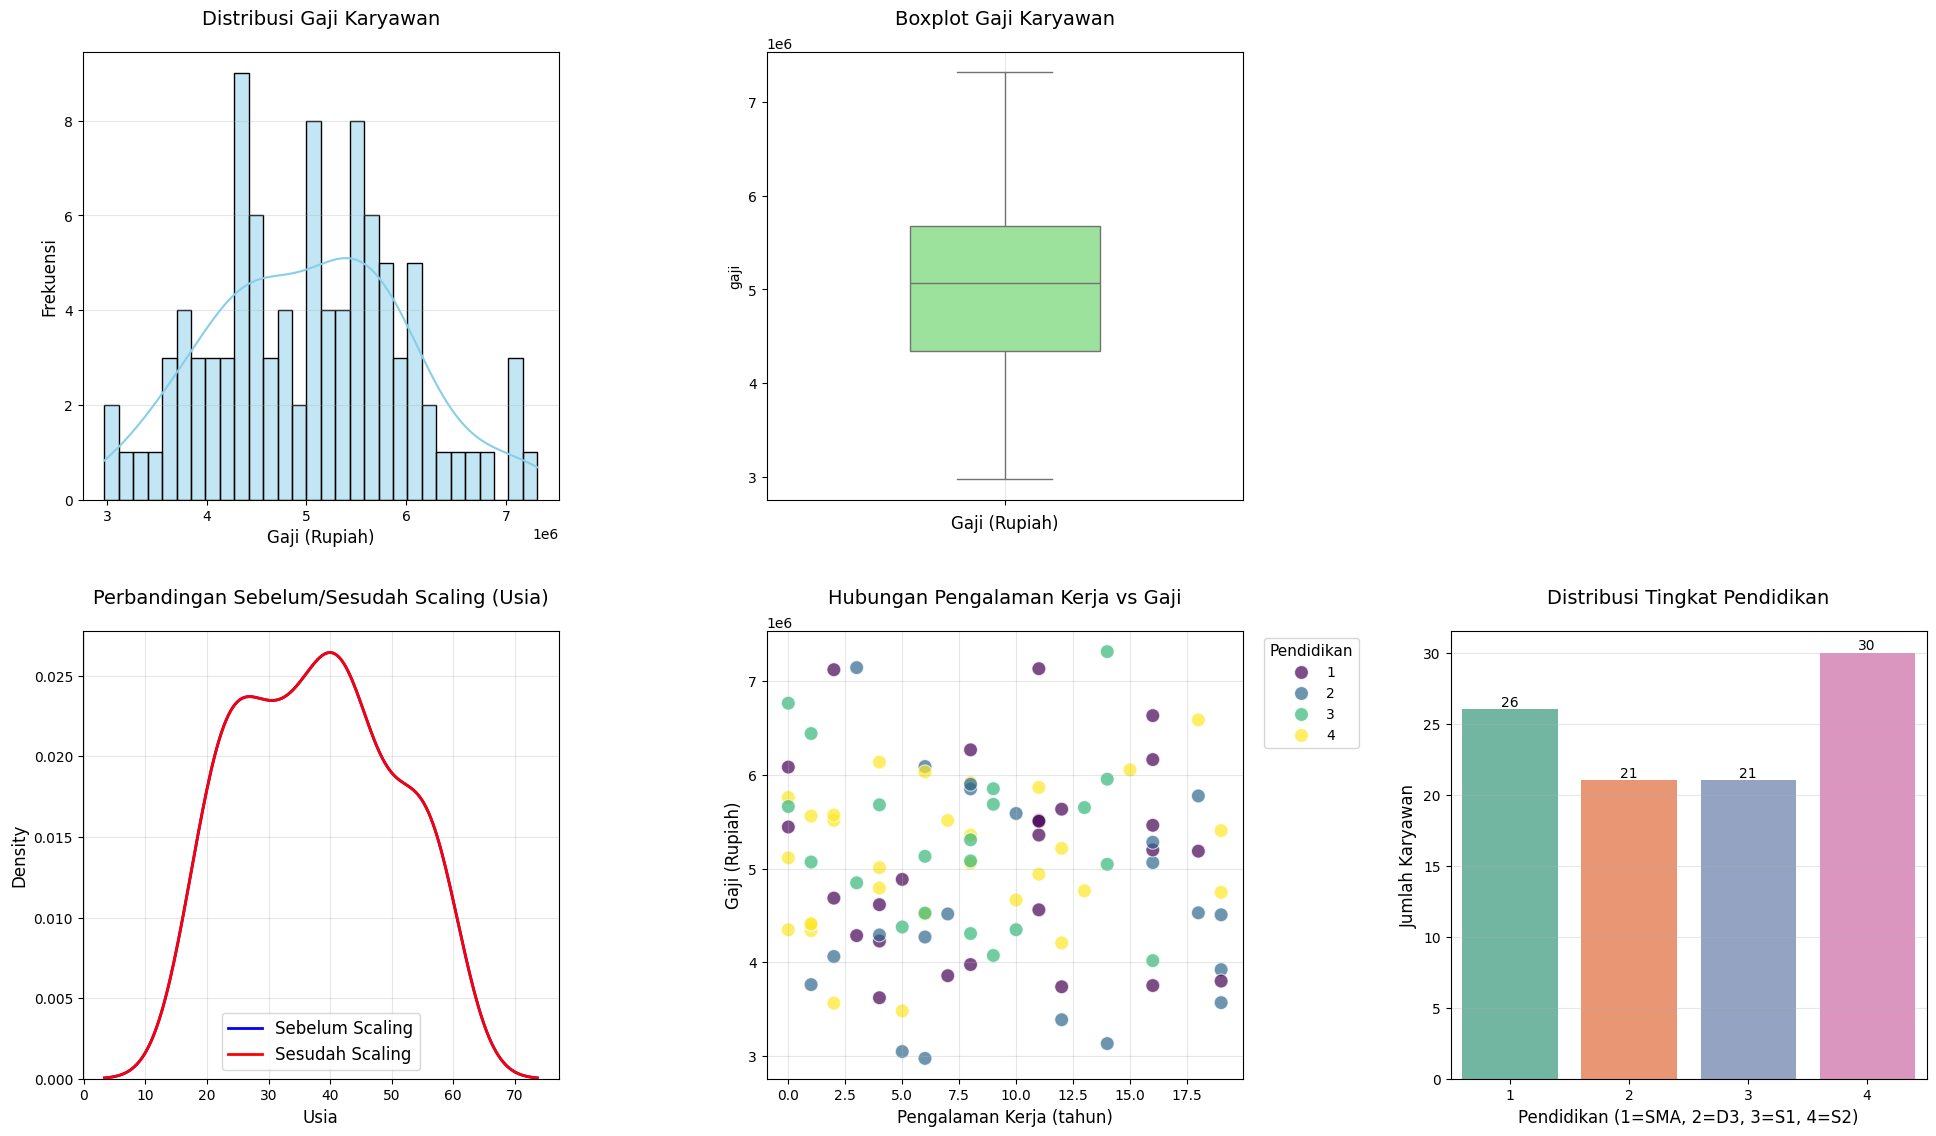

In [ ]:
# Set up the figure
plt.figure(figsize=(20, 12))

# Visual 1: Distribusi Gaji
plt.subplot(2, 3, 1)
sns.histplot(y, kde=True, bins=30, color='skyblue')
plt.title('Distribusi Gaji Karyawan', fontsize=14, pad=20)
plt.xlabel('Gaji (Rupiah)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', alpha=0.3)

# Visual 2: Boxplot Gaji
plt.subplot(2, 3, 2)
sns.boxplot(y=y, color='lightgreen', width=0.4)
plt.title('Boxplot Gaji Karyawan', fontsize=14, pad=20)
plt.xlabel('Gaji (Rupiah)', fontsize=12)
plt.xticks(fontsize=10)
plt.grid(axis='x', alpha=0.3)

# Visual 4: Sebelum vs Sesudah Scaling (Usia)
plt.subplot(2, 3, 4)
sns.kdeplot(df['usia'].dropna(), label='Sebelum Scaling', color='blue', linewidth=2)
sns.kdeplot(X['usia'].dropna(), label='Sesudah Scaling', color='red', linewidth=2)
plt.title('Perbandingan Sebelum/Sesudah Scaling (Usia)', fontsize=14, pad=20)
plt.xlabel('Usia', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(alpha=0.3)

# Visual 5: Hubungan Pengalaman Kerja vs Gaji
plt.subplot(2, 3, 5)
scatter = sns.scatterplot(x=df['pengalaman_kerja'], y=y, hue=df['pendidikan'],
                          palette='viridis', s=100, alpha=0.7)
plt.title('Hubungan Pengalaman Kerja vs Gaji', fontsize=14, pad=20)
plt.xlabel('Pengalaman Kerja (tahun)', fontsize=12)
plt.ylabel('Gaji (Rupiah)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(alpha=0.3)
plt.legend(title='Pendidikan', bbox_to_anchor=(1.03, 1), loc='upper left', fontsize=10, title_fontsize=11)

# Visual 6: Distribusi Pendidikan
plt.subplot(2, 3, 6)
bar = sns.countplot(x='pendidikan', data=df, palette='Set2')
plt.title('Distribusi Tingkat Pendidikan', fontsize=14, pad=20)
plt.xlabel('Pendidikan (1=SMA, 2=D3, 3=S1, 4=S2)', fontsize=12)
plt.ylabel('Jumlah Karyawan', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', alpha=0.3)

# Tambahkan label pada setiap batang
for p in bar.patches:
    bar.annotate(f'{p.get_height():.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center',
                 xytext=(0, 5),
                 textcoords='offset points',
                 fontsize=10)

# Tata letak agar tidak saling tumpang tindih
plt.tight_layout(pad=3.0)

# Tampilkan semua plot
plt.show()


Model

Linear Regresion

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
lr_model = LinearRegression()

In [ ]:
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = lr_model.predict(X_test)
y_train_pred = lr_model.predict(X_train)

In [ ]:
print("MAE:", mt.mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mt.mean_squared_error(y_test, y_pred)))
print("R-squared test:", round(mt.r2_score(y_test, y_pred), 3))
print("R-squared train:", round(mt.r2_score(y_train, y_train_pred), 3))

MAE: 623886.4329501037
RMSE: 800208.1628027576
R-squared test: -0.072
R-squared train: 0.009


Random Forest

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)
y_train_pred = rf_model.predict(X_train)

In [ ]:
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
print("R-squared test:", round(r2_score(y_test, y_pred), 3))
print("R-squared train:", round(r2_score(y_train, y_train_pred), 3))

MAE: 744616.5
RMSE: 974268.32
R-squared test: -0.589
R-squared train: 0.826


gradient boosting

In [ ]:
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.2, random_state=42)

In [ ]:
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.2, random_state=42)

In [ ]:
y_pred = gb_model.predict(X_test)
y_train_pred = gb_model.predict(X_train)

In [ ]:
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
print("R-squared test:", round(r2_score(y_test, y_pred), 3))
print("R-squared train:", round(r2_score(y_train, y_train_pred), 3))

MAE: 908844.77
RMSE: 1125862.19
R-squared test: -1.122
R-squared train: 0.986


1.Nedia Waty adalah seorang pengusaha muda yang mendirikan sebuah start-up teknologi informasi yang sedang berkembang pesat. Kini, perusahaannya mulai merekrut banyak karyawan baru dari berbagai latar belakang.

Namun, Nedia menghadapi tantangan:
➡️ Bagaimana cara menentukan gaji yang adil dan kompetitif untuk calon karyawan baru?
➡️ Apa saja faktor yang benar-benar mempengaruhi besar kecilnya gaji di perusahaannya selama ini?

Untuk menjawab pertanyaan ini, Nedia memutuskan untuk membangun sebuah model prediksi gaji berbasis machine learning yang bisa digunakan oleh Nedia. Ia sudah menyiapkan dataset berisi informasi historis karyawan, meliputi:

1. Usia

2. Pengalaman kerja

3. Jenis kelamin

4. Tingkat pendidikan

5. Gaji

Bantulah Nedia untuk memprediksi gaji karyawannya dengan menggunakan data_karyawan.csv yang sudah disediakan Nedia.

Nah jadi pada kodingan diatas menjelaskan
Faktor yang Memengaruhi Gaji:
berupa Usia, pengalaman kerja, dan tingkat pendidikan adalah faktor kunci dalam menentukan gaji.


Model Prediksi Gaji:
Nedia dapat menggunakan analisis ini untuk membangun model machine learning yang mempertimbangkan fitur-fitur (usia, pengalaman, pendidikan) untuk memprediksi gaji karyawan yang adil dan kompetitif.


Langkah Selanjutnya:
Mengolah dataset (data_karyawan.csv) untuk melatih model prediksi dengan menggunakan algoritma seperti Regresi Linier, Random Forest, atau algoritma lainnya.
Menguji model dengan data baru untuk memastikan keakuratannya dalam memprediksi gaji.

---------------------------------------------------------------------------------------------------------------------------------------------------------------

2.Jelaskan peran fitur enginering dalam pemodelan macine learning.jelaskancontohnya dari kodingan?

Fitur engineering adalah proses penting dalam machine learning yang melibatkan pemilihan, transformasi, atau pembuatan fitur baru dari data mentah untuk meningkatkan kinerja model. Dalam konteks ini, saya menggunakan Linear Regression, Random Forest Regressor, dan Gradient Boosting Regressor supaya menghasilkan kinerja model yang lebih baik.

---------------------------------------------------------------------------------------------------------------------------------------------------------------

3.Apa itu confusion matrix dan metrik evaluasi jika dilihat dari studi kasus

Confusion matrix adalah alat yang digunakan untuk mengevaluasi kinerja model klasifikasi dengan membandingkan prediksi model dengan hasil aktual. Dalam konteks data yang diberikan, kita dapat menggunakan confusion matrix untuk menganalisis hasil prediksi model terhadap data karyawan, misalnya, dalam klasifikasi apakah seorang karyawan akan mendapatkan gaji di atas atau di bawah rata-rata.

Sementara Marix Evaluasi pada Regresi seperti diatas berupa :
Pada regresi, kita lebih sering menggunakan metrik evaluasi seperti 
1.  Mean Squared Error (MSE), 
2.  Mean Absolute Error (MAE),
2.  R-squared (R^2), 
3.  Mean Absolute Error (MAE), 
dan sebagainya. Metrik-metrik ini membantu kita mengukur seberapa baik model regresi memetakan data input ke output yang tepat. Jadi, perbedaan utamanya adalah confusion matrix digunakan untuk klasifikasi, sementara metrik evaluasi regresi digunakan untuk regresi.


nah untuk confusion matrix pada klasifikasi berupa:
True Positive (TP): Model memprediksi positif, dan memang benar datanya positif.

True Negative (TN): Model memprediksi negatif, dan benar datanya negatif.

False Positive (FP): Model memprediksi positif, tapi sebenarnya negatif.

False Negative (FN): Model memprediksi negatif, tapi sebenarnya positif.
Sementara Matrix Evaluasi pada klasifikasi  :
berisikan
1.  Akurasi
2.  presisi
3.  recall
4.  F1 score

-Akurasi memberikan gambaran umum tentang kinerja model, tetapi bisa menyesatkan jika data tidak seimbang.

-Presisi dan recall memberikan informasi lebih mendalam tentang kualitas prediksi positif.

-F1 score adalah metrik yang berguna untuk menyeimbangkan presisi dan recall, terutama dalam situasi di mana salah satu dari keduanya lebih penting.